In [1]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# Notebook 5: Model Evaluation & Comparison
# ============================================================
# This notebook covers:
# - Load all trained models
# - Evaluate on test set
# - Compare accuracy, precision, recall, F1
# - Confusion matrices for all models
# - Training history visualization
# - Identify best model for deployment
# ============================================================

In [2]:
# Mount Drive

from google.colab import drive
import shutil
shutil.rmtree('/content/drive', ignore_errors=True)
drive.mount('/content/drive')
print(" Google Drive mounted")

Mounted at /content/drive
 Google Drive mounted


In [3]:
#  Import Libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

print(f" TensorFlow : {tf.__version__}")
print(f" GPU        : {tf.config.list_physical_devices('GPU')}")

 TensorFlow : 2.20.0
 GPU        : []


In [4]:
#  Paths & Parameters

BASE_DIR   = "/content/drive/MyDrive/BrainTumor"
TEST_DIR   = os.path.join(BASE_DIR, "test")
MODELS_DIR = os.path.join(BASE_DIR, "models")

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
CLASSES     = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
NUM_CLASSES = 4

print(f" Test dir   : {TEST_DIR}")
print(f" Models dir : {MODELS_DIR}")
print("\nModels available:")
for f in os.listdir(MODELS_DIR):
    size = os.path.getsize(os.path.join(MODELS_DIR, f))
    print(f"  {f}  →  {size/1024/1024:.2f} MB")

 Test dir   : /content/drive/MyDrive/BrainTumor/test
 Models dir : /content/drive/MyDrive/BrainTumor/models

Models available:
  custom_cnn.h5  →  7.98 MB
  custom_cnn_history.png  →  0.13 MB
  custom_cnn_confusion_matrix.png  →  0.06 MB
  efficientnetb0_phase1_history.png  →  0.10 MB
  efficientnetb0_phase2_history.png  →  0.09 MB
  efficientnetb0.h5  →  31.78 MB
  efficientnetb0_confusion_matrix.png  →  0.06 MB
  mobilenetv2_phase1_history.png  →  0.10 MB
  mobilenetv2.h5  →  25.00 MB
  mobilenetv2_phase2_history.png  →  0.09 MB
  mobilenetv2_confusion_matrix.png  →  0.06 MB
  resnet50_phase1_history.png  →  0.09 MB
  resnet50.h5  →  207.28 MB
  resnet50_phase2_history.png  →  0.09 MB
  resnet50_confusion_matrix.png  →  0.06 MB
  model_results.csv  →  0.00 MB


In [5]:
#  Load All Models

print("Loading all trained models...")
print("=" * 45)

custom_cnn  = load_model(os.path.join(MODELS_DIR, "custom_cnn.h5"))
print(" Custom CNN loaded")

efficientnet = load_model(os.path.join(MODELS_DIR, "efficientnetb0.h5"))
print(" EfficientNetB0 loaded")

mobilenet   = load_model(os.path.join(MODELS_DIR, "mobilenetv2.h5"))
print(" MobileNetV2 loaded")

resnet      = load_model(os.path.join(MODELS_DIR, "resnet50.h5"))
print(" ResNet50 loaded")

print("\n All 4 models loaded successfully!")

Loading all trained models...


 Custom CNN loaded


 EfficientNetB0 loaded


 MobileNetV2 loaded


 ResNet50 loaded

 All 4 models loaded successfully!


In [6]:
#  Create Test Generators

# Standard test generator
test_datagen     = ImageDataGenerator(rescale=1./255)

# EfficientNet test generator
test_datagen_eff = ImageDataGenerator(
    preprocessing_function=eff_preprocess
)

# Standard (for CNN, MobileNet, ResNet)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES, shuffle=False
)

# EfficientNet specific
test_gen_eff = test_datagen_eff.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES, shuffle=False
)

print(f" Test samples : {test_gen.n}")
print(f" Classes      : {test_gen.class_indices}")

Found 246 images belonging to 4 classes.
Found 246 images belonging to 4 classes.
 Test samples : 246
 Classes      : {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


In [7]:
# Evaluate All Models

def get_predictions(model, test_generator):
    test_generator.reset()
    predictions  = model.predict(test_generator, verbose=0)
    pred_classes = np.argmax(predictions, axis=1)
    true_classes = test_generator.classes
    loss, acc    = model.evaluate(test_generator, verbose=0)
    return pred_classes, true_classes, predictions, acc, loss

print("Evaluating all models on test set...")
print("=" * 50)

# Get predictions for all models
pred_cnn,  true_cnn,  prob_cnn,  acc_cnn,  loss_cnn  = get_predictions(custom_cnn,   test_gen)
pred_eff,  true_eff,  prob_eff,  acc_eff,  loss_eff  = get_predictions(efficientnet, test_gen_eff)
pred_mob,  true_mob,  prob_mob,  acc_mob,  loss_mob  = get_predictions(mobilenet,    test_gen)
pred_res,  true_res,  prob_res,  acc_res,  loss_res  = get_predictions(resnet,       test_gen)

print(" All predictions obtained!")
print(f"\n  Custom CNN     : {acc_cnn*100:.2f}%")
print(f"  EfficientNetB0 : {acc_eff*100:.2f}%")
print(f"  MobileNetV2    : {acc_mob*100:.2f}%")
print(f"  ResNet50       : {acc_res*100:.2f}%")

Evaluating all models on test set...


 All predictions obtained!

  Custom CNN     : 69.11%
  EfficientNetB0 : 91.46%
  MobileNetV2    : 91.06%
  ResNet50       : 80.08%


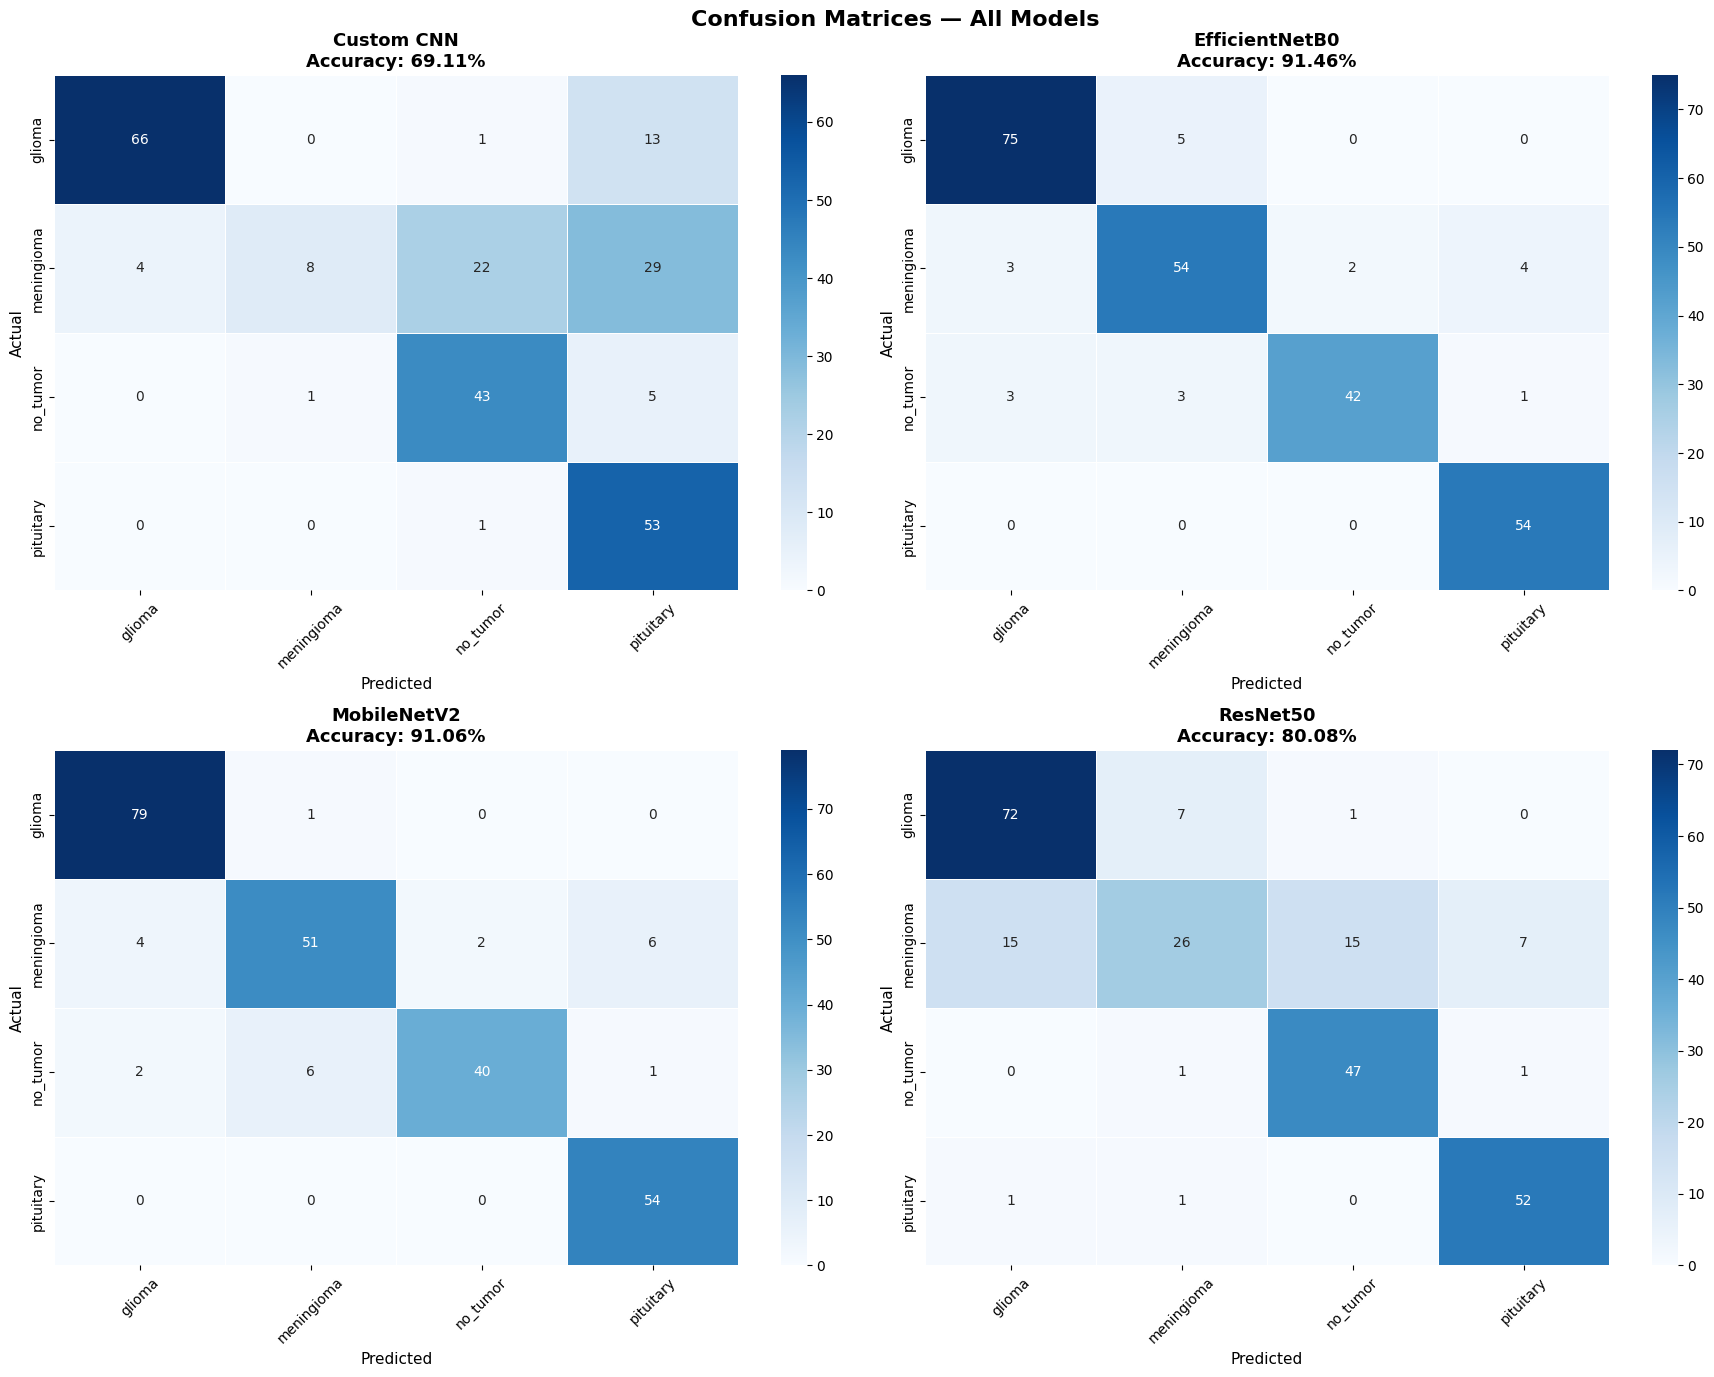

 All confusion matrices saved


In [8]:
# Confusion Matrices All Models

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold')

models_data = [
    ("Custom CNN",     true_cnn,  pred_cnn,  axes[0,0]),
    ("EfficientNetB0", true_eff,  pred_eff,  axes[0,1]),
    ("MobileNetV2",    true_mob,  pred_mob,  axes[1,0]),
    ("ResNet50",       true_res,  pred_res,  axes[1,1]),
]

for model_name, true, pred, ax in models_data:
    cm = confusion_matrix(true, pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASSES, yticklabels=CLASSES,
        linewidths=0.5, ax=ax
    )
    acc = np.trace(cm) / np.sum(cm)
    ax.set_title(f'{model_name}\nAccuracy: {acc*100:.2f}%',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'all_confusion_matrices.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(" All confusion matrices saved")

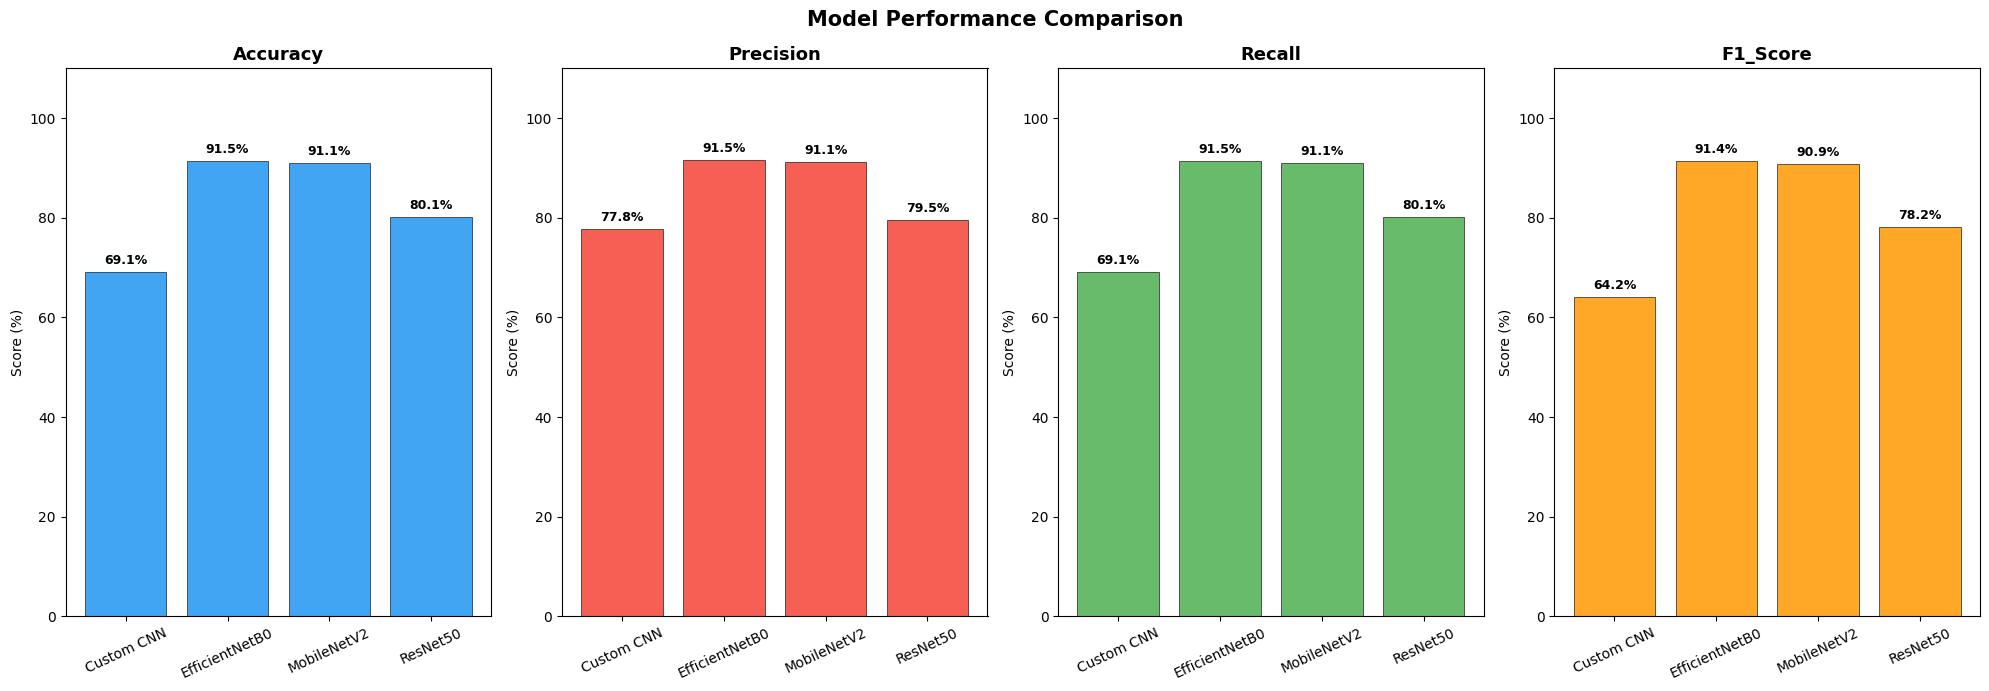

 Metrics comparison chart saved


In [9]:
# Metrics Comparison Bar Chart

# Calculate all metrics
results = []
models_info = [
    ("Custom CNN",     true_cnn,  pred_cnn,  acc_cnn,  loss_cnn),
    ("EfficientNetB0", true_eff,  pred_eff,  acc_eff,  loss_eff),
    ("MobileNetV2",    true_mob,  pred_mob,  acc_mob,  loss_mob),
    ("ResNet50",       true_res,  pred_res,  acc_res,  loss_res),
]

for name, true, pred, acc, loss in models_info:
    results.append({
        'Model'    : name,
        'Accuracy' : round(acc * 100, 2),
        'Precision': round(precision_score(true, pred, average='weighted'), 4),
        'Recall'   : round(recall_score(true, pred, average='weighted'), 4),
        'F1_Score' : round(f1_score(true, pred, average='weighted'), 4),
        'Loss'     : round(loss, 4)
    })

df_results = pd.DataFrame(results)

# Plot
fig, axes = plt.subplots(1, 4, figsize=(20, 7))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

metrics   = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
colors    = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
bar_color = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']

for ax, metric, color in zip(axes, metrics, bar_color):
    values = df_results[metric].values
    if metric == 'Accuracy':
        display_values = values
    else:
        display_values = values * 100

    bars = ax.bar(df_results['Model'], display_values,
                  color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score (%)')
    ax.set_ylim([0, 110])
    ax.tick_params(axis='x', rotation=25)

    for bar, val in zip(bars, display_values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f'{val:.1f}%', ha='center',
                va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'metrics_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(" Metrics comparison chart saved")

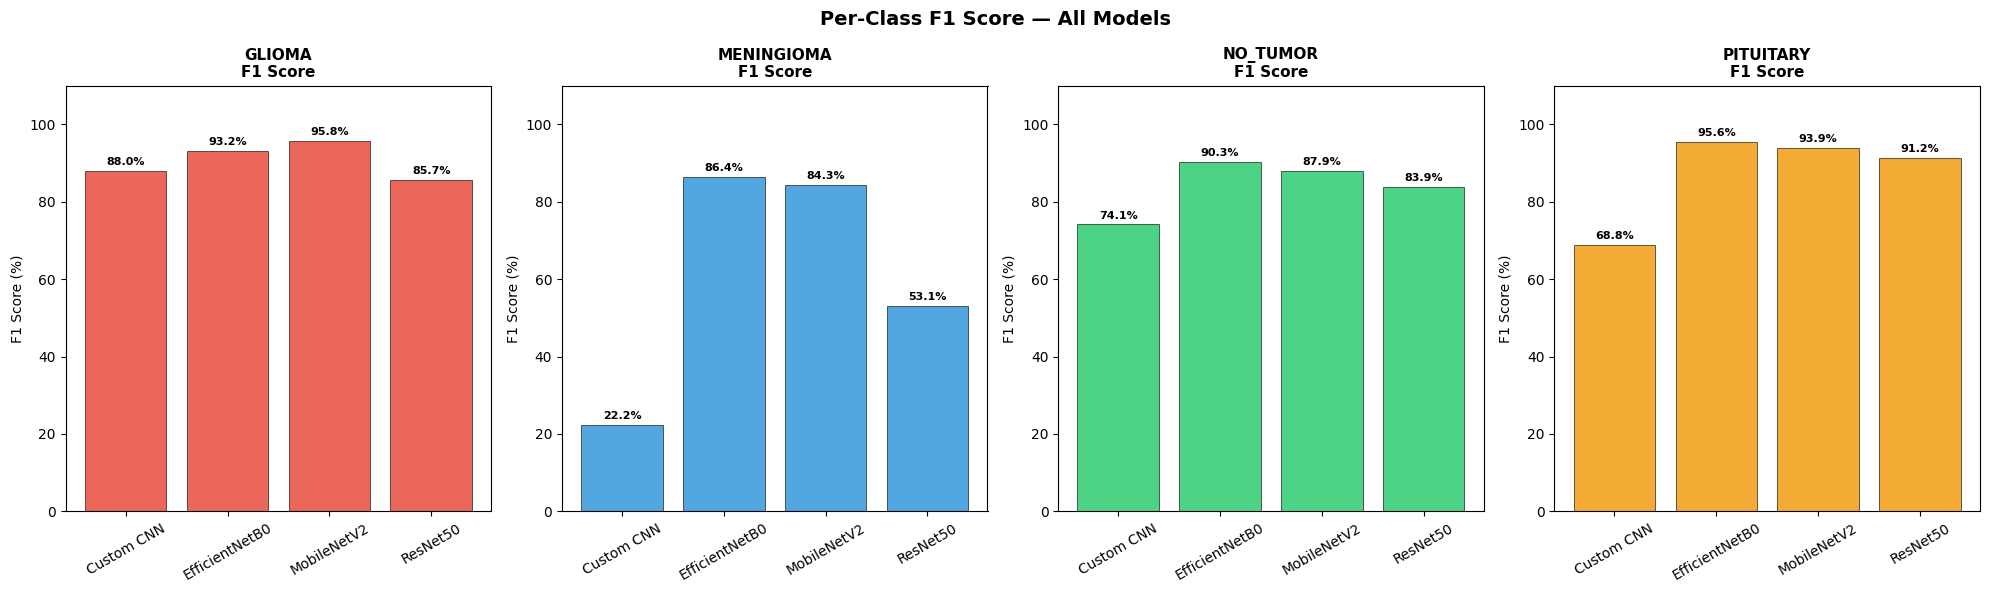

 Per-class F1 comparison saved


In [10]:
#  Per Class F1 Comparison

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('Per-Class F1 Score — All Models', fontsize=14, fontweight='bold')

class_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for ax, cls_idx, cls_name, color in zip(axes, range(4), CLASSES, class_colors):
    f1_scores = []
    model_names = []

    for name, true, pred, acc, loss in models_info:
        report = classification_report(
            true, pred, target_names=CLASSES,
            output_dict=True
        )
        f1_scores.append(report[cls_name]['f1-score'] * 100)
        model_names.append(name)

    bars = ax.bar(model_names, f1_scores, color=color,
                  alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{cls_name.upper()}\nF1 Score', fontsize=11, fontweight='bold')
    ax.set_ylim([0, 110])
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel('F1 Score (%)')

    for bar, val in zip(bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f'{val:.1f}%', ha='center',
                va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'per_class_f1_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(" Per-class F1 comparison saved")

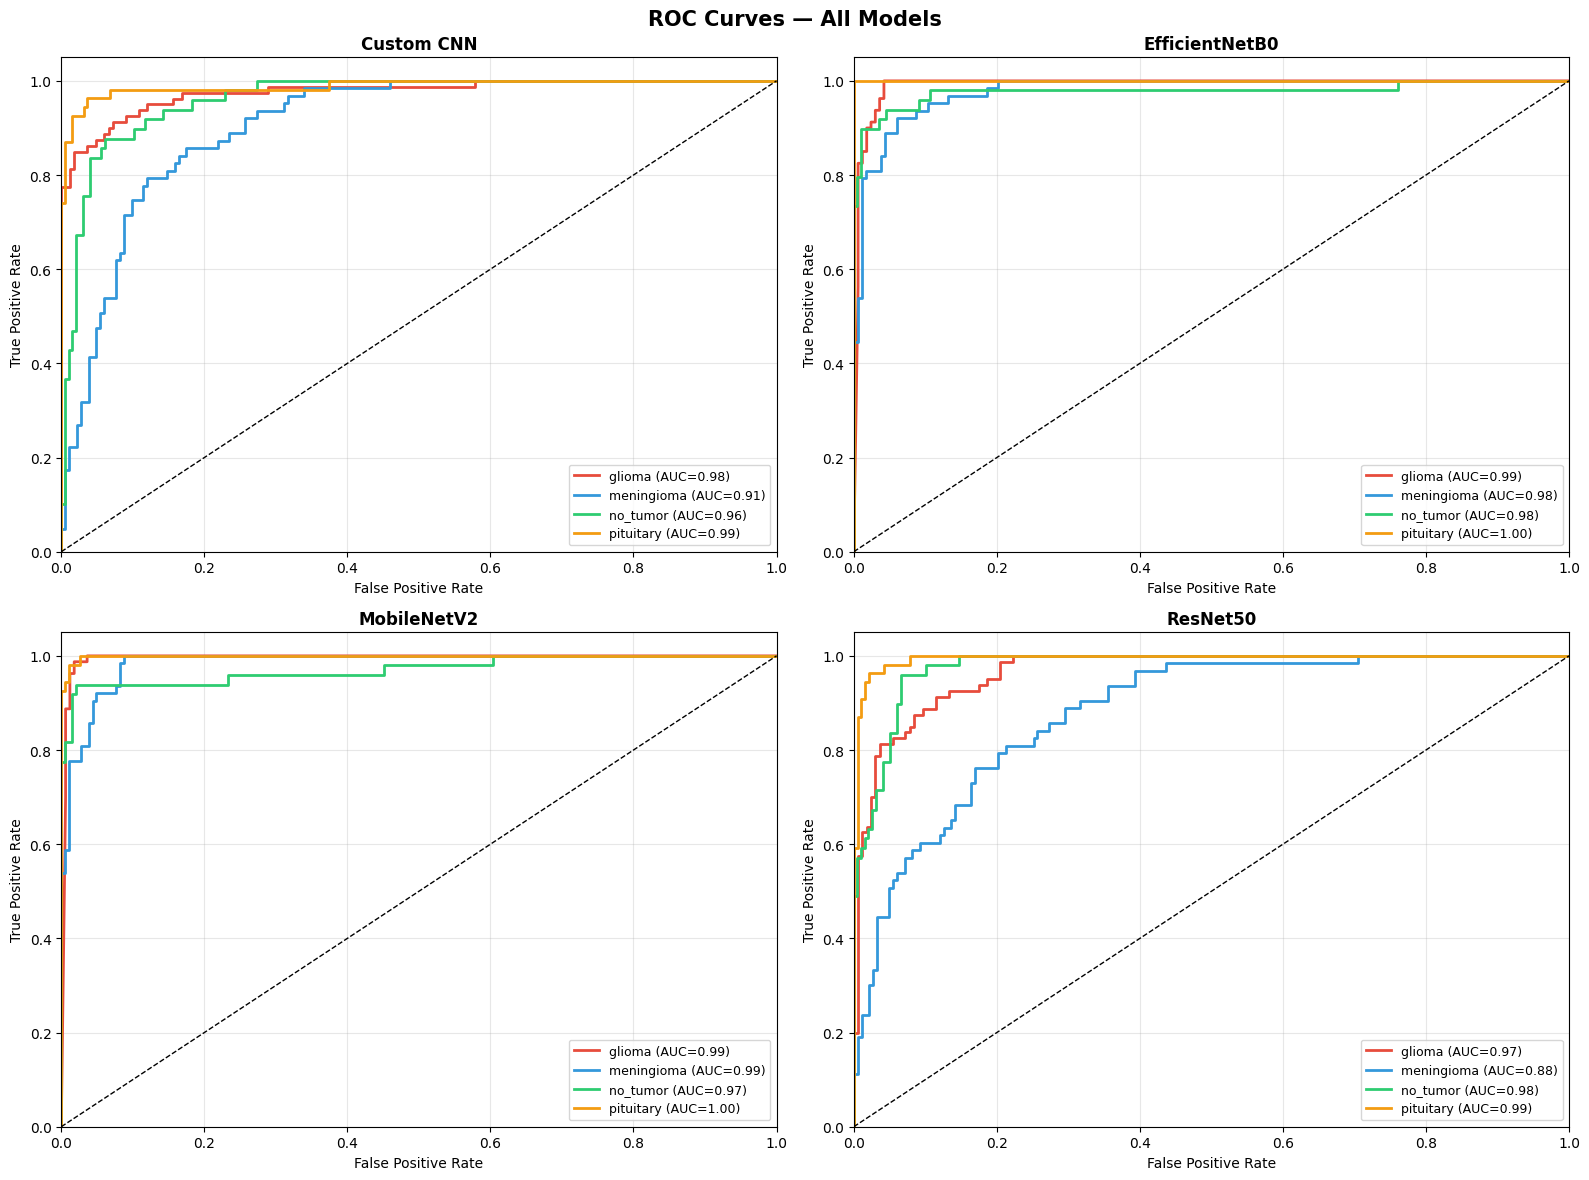

 ROC curves saved


In [11]:
#  ROC Curves

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ROC Curves — All Models', fontsize=15, fontweight='bold')

true_bin = label_binarize(true_cnn, classes=[0, 1, 2, 3])

roc_data = [
    ("Custom CNN",     prob_cnn,  axes[0,0]),
    ("EfficientNetB0", prob_eff,  axes[0,1]),
    ("MobileNetV2",    prob_mob,  axes[1,0]),
    ("ResNet50",       prob_res,  axes[1,1]),
]

roc_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for model_name, probs, ax in roc_data:
    for i, (cls, color) in enumerate(zip(CLASSES, roc_colors)):
        fpr, tpr, _ = roc_curve(true_bin[:, i], probs[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f'{cls} (AUC={roc_auc:.2f})')

    ax.plot([0,1], [0,1], 'k--', linewidth=1)
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'roc_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(" ROC curves saved")

In [12]:
#  Final Summary & Best Model

print("=" * 60)
print("      FINAL MODEL COMPARISON SUMMARY")
print("=" * 60)
print(df_results.to_string(index=False))
print("=" * 60)

# Find best model
best_idx   = df_results['Accuracy'].idxmax()
best_model = df_results.loc[best_idx]

print(f"""
 BEST MODEL : {best_model['Model']}
   Accuracy   : {best_model['Accuracy']}%
   Precision  : {best_model['Precision']}
   Recall     : {best_model['Recall']}
   F1 Score   : {best_model['F1_Score']}
   Loss       : {best_model['Loss']}

 DEPLOYMENT DECISION:
   → {best_model['Model']} selected for Streamlit app
   → Model file : {best_model['Model'].lower().replace(' ','_')}.h5

 KEY INSIGHTS:
   → Transfer learning gave {best_model['Accuracy'] - 65.04:.2f}% improvement over Custom CNN
   → Meningioma was hardest class across all models
   → EfficientNetB0 best balance of accuracy & efficiency
""")
print("=" * 60)

# Save final results
df_results.to_csv(
    os.path.join(MODELS_DIR, 'model_results.csv'),
    index=False
)
print(" Final results saved to model_results.csv")
print("\n  Next Step → Notebook 6: Streamlit App")

      FINAL MODEL COMPARISON SUMMARY
         Model  Accuracy  Precision  Recall  F1_Score   Loss
    Custom CNN     69.11     0.7784  0.6911    0.6419 0.7485
EfficientNetB0     91.46     0.9152  0.9146    0.9140 0.3824
   MobileNetV2     91.06     0.9115  0.9106    0.9086 0.4777
      ResNet50     80.08     0.7952  0.8008    0.7821 0.4477

 BEST MODEL : EfficientNetB0
   Accuracy   : 91.46%
   Precision  : 0.9152
   Recall     : 0.9146
   F1 Score   : 0.914
   Loss       : 0.3824

 DEPLOYMENT DECISION:
   → EfficientNetB0 selected for Streamlit app
   → Model file : efficientnetb0.h5

 KEY INSIGHTS:
   → Transfer learning gave 26.42% improvement over Custom CNN
   → Meningioma was hardest class across all models
   → EfficientNetB0 best balance of accuracy & efficiency

 Final results saved to model_results.csv

  Next Step → Notebook 6: Streamlit App
